# Salary Prediction - Exploratory Data Analysis (EDA)

## Project Goal :
Predict Salary based on Age, Gender, Education Level, Job Title and Years of Experience.

### Import Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [34]:
df = pd.read_csv("data/raw/salary_data.csv")

In [35]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


### Basic Info

In [36]:
df.shape

(6704, 6)

In [37]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [39]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


### Missing Values Check

In [40]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

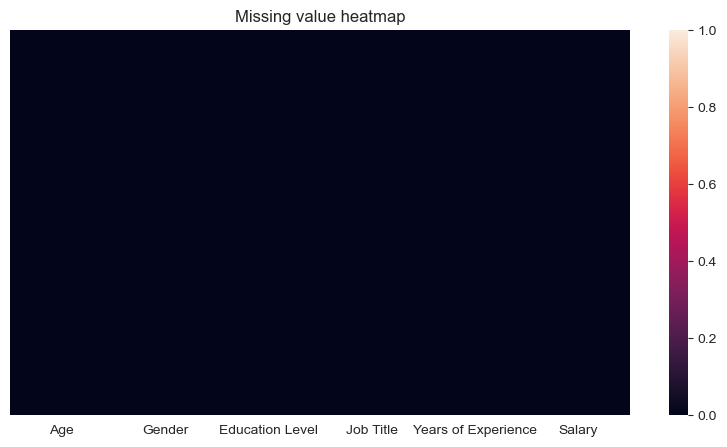

In [41]:
# Missing value check heatmap

plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), yticklabels=False)
plt.title('Missing value heatmap')
plt.show()

### Duplicate values check

In [44]:
df.duplicated().value_counts()

True     4912
False    1792
Name: count, dtype: int64

In [45]:
df.duplicated().sum()


np.int64(4912)

### Categorical vs Numerical Column Identify

In [48]:
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)

print('Numerical columns :', num_cols)

Numerical columns : ['Age', 'Years of Experience', 'Salary']


In [49]:
cat_cols = list(df.select_dtypes(include=['object']).columns)
print('Categorical columns :',cat_cols)

Categorical columns : ['Gender', 'Education Level', 'Job Title']


## Numerical Feature Analysis 

In [50]:
# Statical Summery

df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


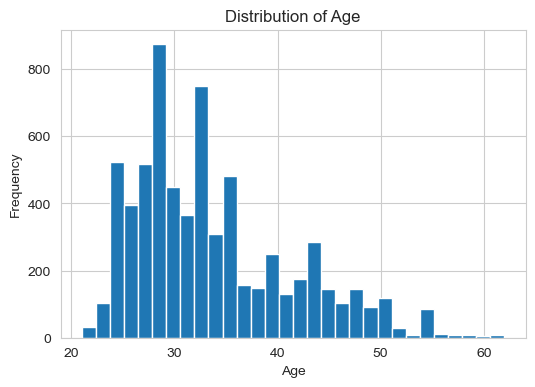

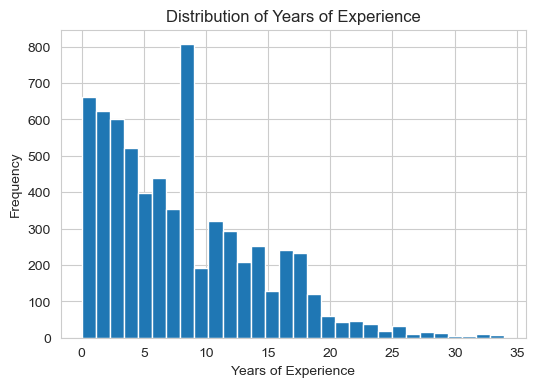

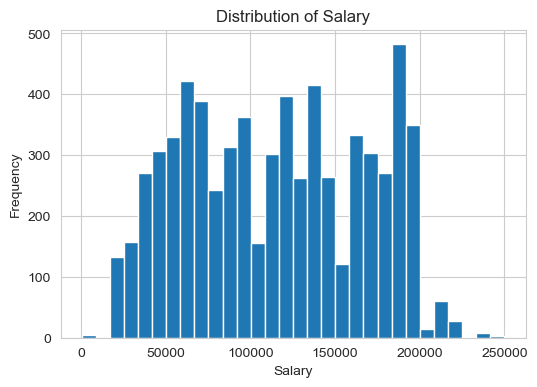

In [51]:
# Distribution Analysis

for col in num_cols:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

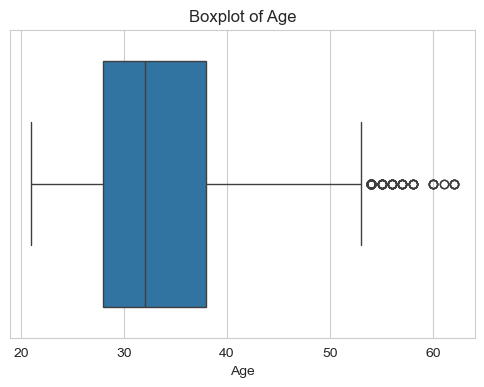

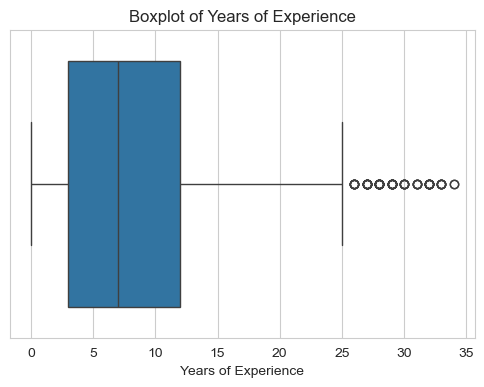

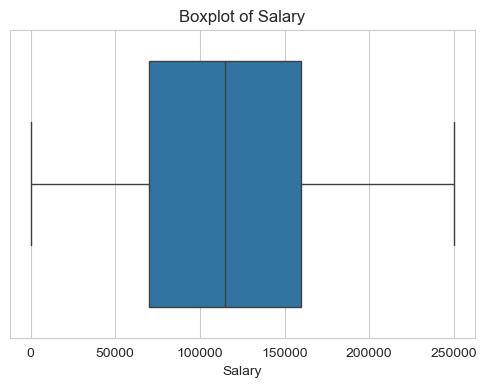

In [52]:
# Outlier Detection (Boxplot)

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [53]:
# Correlation Analysis

cor_metrix = df[num_cols].corr()
print(cor_metrix)

                          Age  Years of Experience    Salary
Age                  1.000000             0.937655  0.728053
Years of Experience  0.937655             1.000000  0.808969
Salary               0.728053             0.808969  1.000000


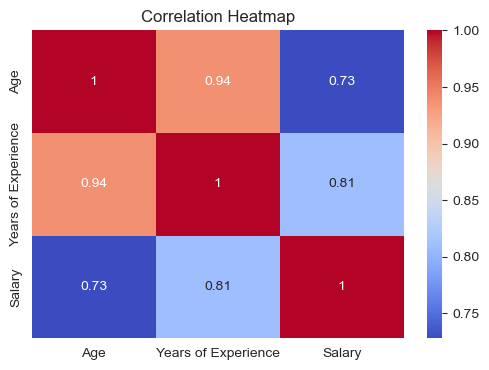

In [54]:
# Correlation Hearmap

plt.figure(figsize=(6,4))
sns.heatmap(cor_metrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Feature vs Target Relationship


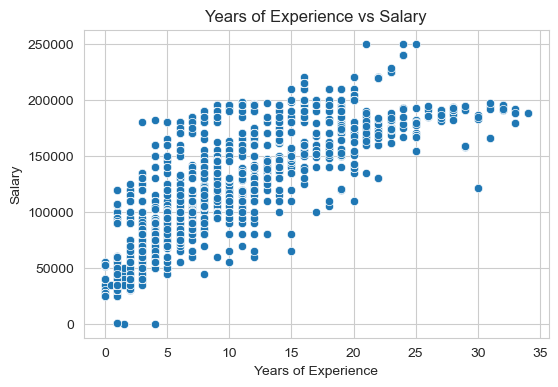

In [55]:
# Years of Experience vs Salary(Scatterplot)

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Years of Experience'], y=df['Salary'])
plt.title('Years of Experience vs Salary')
plt.show()

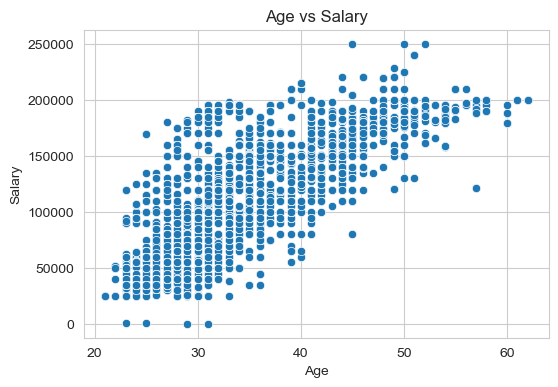

In [56]:
# Age vs Salary (Scatterplot)

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Age'], y=df['Salary'])
plt.title('Age vs Salary')
plt.show()

In [57]:
# Skewness Check

print(df[num_cols].skew())

Age                    0.905596
Years of Experience    0.981188
Salary                 0.057344
dtype: float64


### Categorical Feature Analysis

In [58]:
# Unique Values Checks

for col in cat_cols:
    print(f'\n{col}')
    print(df[col].unique())


Gender
['Male' 'Female' nan 'Other']

Education Level
["Bachelor's" "Master's" 'PhD' nan "Bachelor's Degree" "Master's Degree"
 'High School' 'phD']

Job Title
['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist' 'Software Developer'
 'HR Manager' 'Financial Analyst' 'Project Manager' 'Customer Service Rep'
 'Operations Manager' 'Marketing Manager' 'Senior Engineer'
 'Data Entry Clerk' 'Sales Director' 'Business Analyst' 'VP of Operations'
 'IT Support' 'Recruiter' 'Financial Manager' 'Social Media Specialist'
 'Software Manager' 'Junior Developer' 'Senior Consultant'
 'Product Designer' 'CEO' 'Accountant' 'Data Scientist'
 'Marketing Specialist' 'Technical Writer' 'HR Generalist'
 'Project Engineer' 'Customer Success Rep' 'Sales Executive' 'UX Designer'
 'Operations Director' 'Network Engineer' 'Administrative Assistant'
 'Strategy Consultant' 'Copywriter' '

In [59]:
# Number of uniques Categories

for col in cat_cols:
    print(f'{col} : {df[col].nunique()}')

Gender : 3
Education Level : 7
Job Title : 193


In [60]:
# Categori Frequiency Check

for col in cat_cols:
    print(f'\nValue Counts of {col}')
    print(df[col].value_counts())


Value Counts of Gender
Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64

Value Counts of Education Level
Education Level
Bachelor's Degree    2267
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

Value Counts of Job Title
Job Title
Software Engineer                 518
Data Scientist                    453
Software Engineer Manager         376
Data Analyst                      363
Senior Project Engineer           318
                                 ... 
Junior Social Media Specialist      1
Senior Software Architect           1
Developer                           1
Social M                            1
Social Media Man                    1
Name: count, Length: 193, dtype: int64


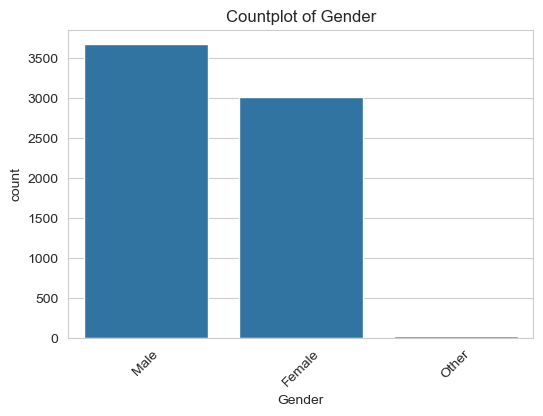

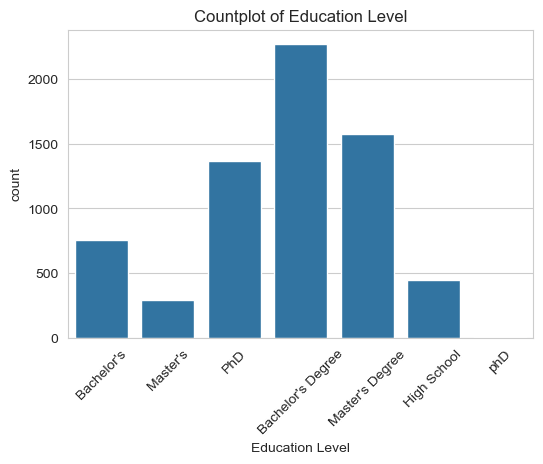

In [61]:
# Categori Frequiency Visualization(Countplot)

small_cat_cols = ['Gender', 'Education Level']


for col in small_cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(x=df[col])

    plt.title(f'Countplot of {col}')

    plt.xticks(rotation=45)

    plt.show()

High cardinality column (Job Title) → Separate visualization

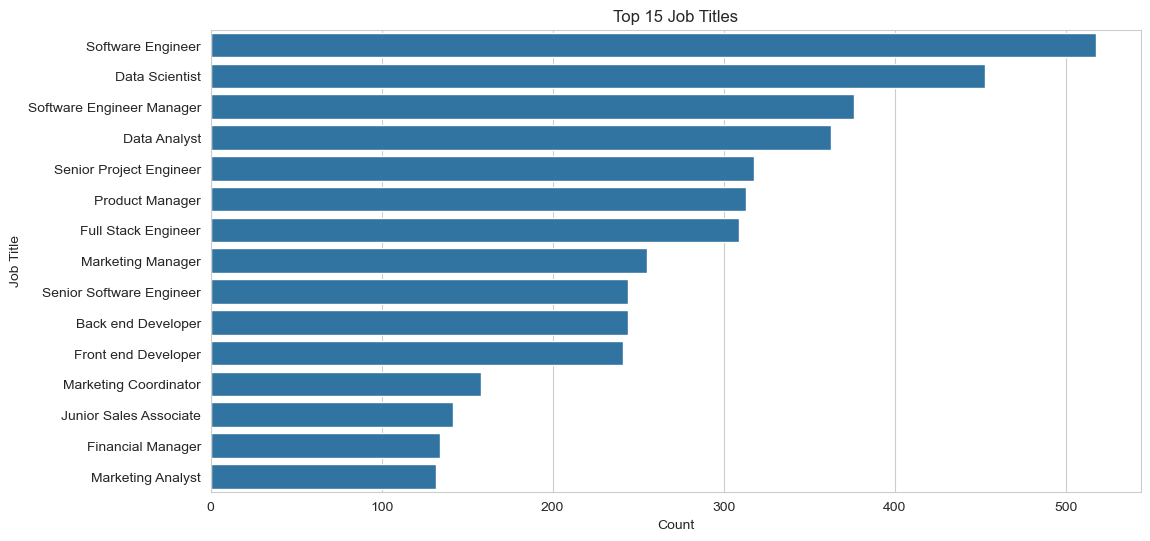

In [62]:
# Top 15 most frequent job titles

top_jobs = df['Job Title'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    y=top_jobs.index,
    x=top_jobs.values
)

plt.title("Top 15 Job Titles")

plt.xlabel("Count")
plt.ylabel("Job Title")


plt.show()

Target Relationship Analysis

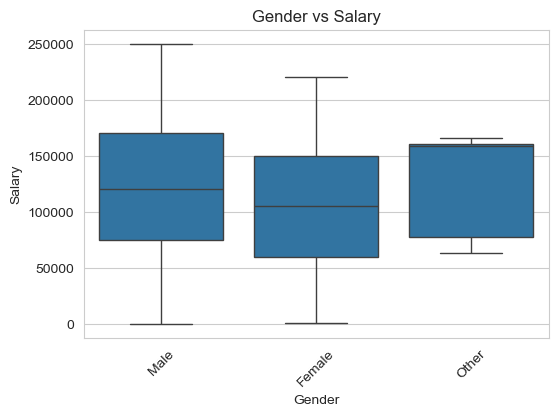

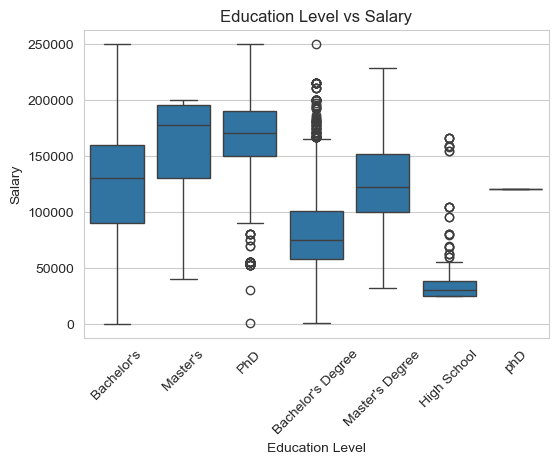

In [63]:
# Boxplot

sns.set_style("whitegrid")

small_cat_cols = ['Gender', 'Education Level']

for col in small_cat_cols:
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x=df[col],
        y=df['Salary']
    )
    
    plt.title(f'{col} vs Salary')
    plt.xticks(rotation=45)
    
    plt.show()

High cardinality column (Job Title) → Separate visualization

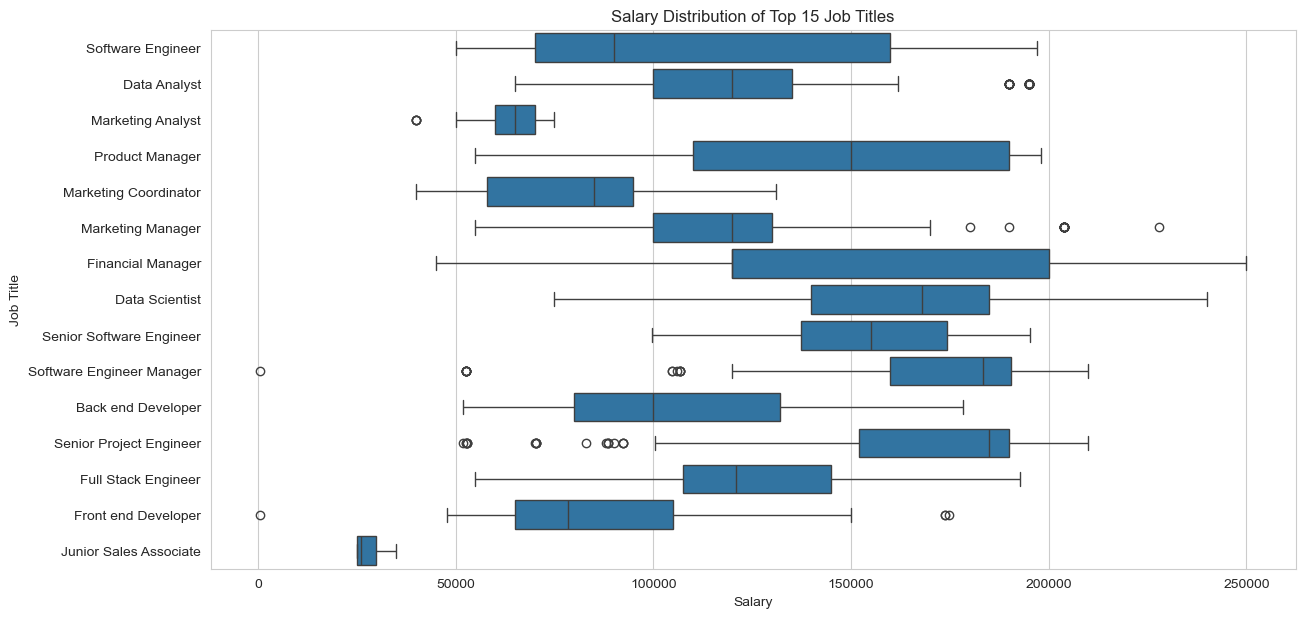

In [64]:
top_15_jobs = df['Job Title'].value_counts().head(15).index

top_jobs = df[df['Job Title'].isin(top_15_jobs)]


plt.figure(figsize=(14,7))

sns.boxplot(
    x='Salary',
    y='Job Title',
    data= top_jobs
)

plt.title("Salary Distribution of Top 15 Job Titles")
plt.xlabel("Salary")
plt.ylabel("Job Title")

plt.show()

## Key Insights from Exploratory Data Analysis (EDA)


The dataset initially contained a large number of duplicate rows, which significantly reduced the effective dataset size after duplicate removal.
A small number of missing values were identified in the following columns:
Age (2)
Gender (2)
Education Level (3)
Job Title (2)
Years of Experience (3)
Salary (5)
The dataset contains both numerical and categorical features:
Numerical Features: Age, Years of Experience, Salary
Categorical Features: Gender, Education Level, Job Title
Years of Experience shows a strong positive correlation with Salary, making it one of the most important predictive features.
Age and Years of Experience are highly correlated, which may introduce multicollinearity in linear models.
The target variable Salary is approximately normally distributed with low skewness.
Years of Experience exhibits moderate positive skewness, while Age shows slight skewness.
The Education Level column contains inconsistent category naming, such as:
"PhD" and "phD"
"Bachelor's" and "Bachelor's Degree"
"Master's" and "Master's Degree"
Job Title has very high cardinality with many unique and rare categories, which may impact encoding efficiency and model generalization.
The gender distribution is relatively balanced between Male and Female, while the Other category contains very few samples.
Higher education levels and senior-level job positions generally correspond to higher salary ranges.
Due to the large number of unique job titles, only the top frequent job titles were visualized for better interpretability.
Overall, the dataset demonstrates meaningful relationships between experience, education, job role, and salary, making it suitable for a salary prediction machine learning project.